In [188]:
beta_dir = "example_data/example_beta_files/"
catalog_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/res/event_catalog.txt"

stn_req = 3.0
nrecords_min = 10
dist_bin_width = 10

dist_max = 100


In [171]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time

import stressdrop_file_IO as sdio
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse


In [42]:

def read_betatxt_files(filedir, ):

    df = pd.DataFrame({
        "stname": pd.arrays.SparseArray(dtype="str", data=[]), 
        "slat": pd.arrays.SparseArray(dtype="float", data=[]), 
        "slon": pd.arrays.SparseArray(dtype="float", data=[]), 
        "selev": pd.arrays.SparseArray(dtype="float", data=[]), 

        "event_id": pd.arrays.SparseArray(dtype="object", data=[]), 
        "qmag": pd.arrays.SparseArray(dtype="object", data=[]), 
        "beta": pd.arrays.SparseArray(dtype="object", data=[]), 
        "stn": pd.arrays.SparseArray(dtype="object", data=[]), 
        "deldist": pd.arrays.SparseArray(dtype="object", data=[]), 
    })

    beta_files = [el for el in os.listdir(filedir) if el.endswith('.betatxt')]

    nfiles = len(beta_files)

    for j in range(nfiles):
        filepath = filedir + beta_files[j]

        low_f_band = np.zeros(2, dtype=float)
        high_f_band = np.zeros(2, dtype=float)

        with open(filepath, 'r') as fp:
            line = fp.readline().strip()

        stname, slat, slon, selev, beta_method, stn_method, low_f_band[0], \
        low_f_band[1], high_f_band[0], high_f_band[1], nevents \
        = line.split("  ")

        # print(line)

        column_names = ['event_id', 'qmag', 'beta', 'stn', 'deldist']
        data = pd.read_csv(filepath, sep='\\s+', skiprows=1, 
            names=column_names)
        event_id = data['event_id'].values
        qmag = data['qmag'].values
        beta = data['beta'].values
        stn = data['stn'].values
        deldist = data['deldist'].values
        df.loc[len(df)] = [stname, slat, slon, selev, event_id, qmag, beta, stn, deldist]

        # print(data)
    df['slat'] = df['slat'].astype(float)
    df['slon'] = df['slon'].astype(float)
    df['selev'] = df['selev'].astype(float)


    return df

def invert_grouping(df, grouping, new_grouping, dependents):
    """ Take a Pandas DataFrame that is grouped by some metric and group
    it by another metric. Example: seismic data is grouped such that each
    line represents one earthquake, and each earthquake contains a variable
    number of seismic stations. Desired new grouping is by station.
    
    Existing dataframe is grouped by 'evid', with 'stid' representing a list 
    of stations for that earthquake. Here, 'evid' and any earthquake-dependent 
    columns are part of 'grouping', and 'stid' and any station-dependent 
    columns are part of 'new_grouping'. Any event-station dependent values
    (e.g. travel-time) are part of 'dependents'.

    Args:
        df (DataFrame): Pandas DataFrame containing original data
        grouping (list): List of column names that are the original grouping
        new_grouping (list): List of column names of the desired grouping
        dependents (list): List of column names dependent on both groupings

    Sources:
        https://stackoverflow.com/q/78694388/25912036

    Last Modified:
        2024-07-08
    """

    df2 = df.explode(new_grouping+dependents)
    df_new = df2.groupby(new_grouping, as_index=False)[grouping+dependents].agg(list)

    return df_new

def filter_stn(row, stn_req, dependents):
    # print(row)
    keep_bool = np.array(row['stn'])>=stn_req

    for el in dependents:
        row[el] = row[el][keep_bool]
    return row
    

In [204]:
cat = pd.read_csv(catalog_dir, sep='\\s+')

dist_bins = np.arange(0, dist_max+1, dist_bin_width)

In [216]:

# These are columns that are station-dependent, event-dependent, and 
# both-dependent.
st_dep = ['stname', 'slat', 'slon', 'selev']
ev_dep = ['event_id', 'qmag']
dependents = ['beta', 'stn', 'deldist']

# read betatxt files into df_sta DataFrame
df_sta = read_betatxt_files(beta_dir)
nstations_initial = len(df_sta)

# explode!
df = df_sta.explode(ev_dep + dependents)
nrecords_initial = len(df)

# get number of initial events
nevents_initial = len(df['event_id'].unique())
print(f"{nevents_initial} events, recorded by {nstations_initial} stations, resulting in {nrecords_initial} records loaded.")

# bin values by distance, first removing distant records
df = df[df['deldist']<=dist_max]
print(f"{nrecords_initial-len(df)} distant (>{dist_max:.1f} km) records removed")
df['distind'] = np.searchsorted(dist_bins, df['deldist'].values.astype(float)) - 1
dependents += ['distind']

# filter out bad STN records
df = df[df['stn']>=stn_req]
df.reset_index(drop=True, inplace=True)
print(f"{len(df)} records ({len(df)/nrecords_initial*100:.1f}%) passed STN ratio requirement of {stn_req:.1f}")

# make sure each earthquake has enough remaining records
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough records (needs >= {nrecords_min})")

# merge eq locations and rename the columns
df_ev = pd.merge(df_ev, cat, how='inner', on='event_id')
df_ev = df_ev.rename({'longitude':'qlon', 'latitude':'qlat', 'depth':'qdep'}, axis=1)
ev_dep += ["qlon", "qlat", "qdep"]
df_ev.reset_index(drop=True, inplace=True)

# add an event index value 'evind' and explode back into df
df_ev['evind'] = df_ev.index.values
ev_dep += ['evind']
df = df_ev.explode(st_dep + dependents)
df.reset_index(drop=True, inplace=True)

# group by station to add index
df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)
df_sta['stind'] = df_sta.index.values
st_dep += ['stind']

# explode!
df = df_sta.explode(ev_dep + dependents)
df.reset_index(drop=True, inplace=True)

# group by event
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents} events")
print(f"{nstations} stations")
print(f"{ndata} records")


12939 events, recorded by 71 stations, resulting in 908378 records loaded.
21514 distant (>100.0 km) records removed
265682 records (29.2%) passed STN ratio requirement of 3.0
3466 events removed due to not enough records (needs >= 10)
-------------
Final counts:
-------------
9411 events
71 stations
246254 records


## Set up G matrix and d array

In [224]:
# d is just the log beta values
d = np.log10(df['beta'].values.astype(float))

# Ge, Gs, and Gr represent the event, station, and distance blocks of G
# d and i arrays are the same for each block: d is just ones, and i are the
# row numbers
d_array = np.ones(ndata, dtype=int) # values at coordinates i,j
i_array = np.arange(ndata, dtype=int) # i coordinates

# Events
j_array = df['evind'].values.astype(int) # j coordinates
Ge = sparse.csc_matrix((d_array, (i_array, j_array)), dtype=int)

# Stations
j_array = df['stind'].values.astype(int) # j coordinates
Gs = sparse.csc_matrix((d_array, (i_array, j_array)), dtype=int)

# Distances
j_array = df['distind'].values.astype(int) # j coordinates
Gr = sparse.csc_matrix((d_array, (i_array, j_array)), dtype=int)

G = sparse.hstack((Ge, Gs, Gr))

In [225]:
print(Ge.shape)
print(Gs.shape)
print(Gr.shape)
print(G.shape)



(246254, 9411)
(246254, 71)
(246254, 10)
(246254, 9492)


In [233]:
x = sparse.linalg.lsqr(G, d, iter_lim=10000)
e = x[0][:nevents]
s = x[0][nevents:nevents+nstations]
r = x[0][nevents+nstations:]

df_ev['event_beta'] = np.power(10, e)

-0.6449433262418005 0.17458013027943553


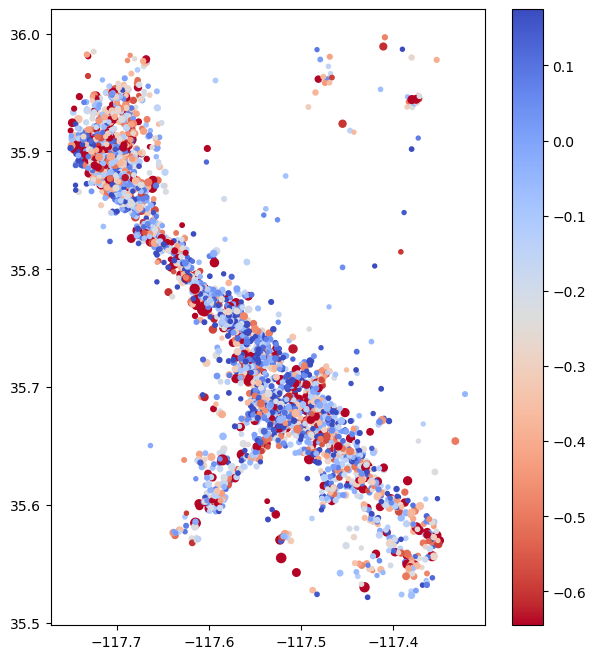

In [241]:
df2 = df_ev[df_ev['qmag']>=2.0]

size = np.power(df2['qmag'].values.astype(float) / 5.0, 2) * 50

betas = np.sort(np.log10(df2['event_beta']))

betas = betas[np.logical_not(np.isnan(betas))]
nbeta = len(betas)

ind1 = int(0.1 * nbeta)
ind2 = int(0.9 * nbeta)

b1 = betas[ind1]
b2 = betas[ind2]

print(betas[ind1], betas[ind2])


plt.figure(figsize=(7,8))

plt.scatter(df2['qlon'], df2['qlat'], s=size, c=np.log10(df2['event_beta']), cmap='coolwarm_r', vmin=b1, vmax = b2)
plt.colorbar()
plt.show()

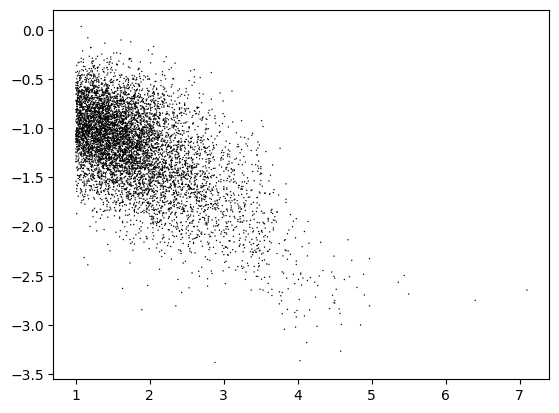

In [55]:
plt.figure()
plt.scatter(df_sta['qmag'][68], np.log10(df_sta['beta'][68]), facecolors='k', edgecolors='none', s=1)
plt.show()

In [144]:
# for i in range(len(df_sta)):
#     assert len(df['stname'][df['stind']==i].unique())==1, print("Uh oh")
# for i in range(len(df_ev)):
#     # print(f'-------- {i}')
#     # print(df['event_id'][df['evind']==i].unique())
#     assert len(df['event_id'][df['evind']==i].unique())==1, print("Uh oh")